In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
import os

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [3]:
def parse_conllu(filepath):
    if not os.path.exists(filepath):
        print(f"Warning: File {filepath} not found.")
        return []
        
    print(f"Reading {filepath}...")
    sentences = []
    current_sent = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                if current_sent:
                    sentences.append(current_sent)
                    current_sent = []
                continue
            parts = line.split('\t')
            # Skip multi-word tokens (1-2) and bad lines
            if len(parts) < 4 or '-' in parts[0]: continue
            current_sent.append((parts[1], parts[3]))
            
    if current_sent: sentences.append(current_sent)
    return sentences
    
train_data = parse_conllu('id_gsd-ud-train.conllu')
test_data = parse_conllu('id_gsd-ud-test.conllu')

if not train_data or not test_data:
    raise ValueError("Data could not be loaded. Please check your .conllu file paths.")

Reading id_gsd-ud-train.conllu...
Reading id_gsd-ud-test.conllu...


In [4]:
word_to_ix = {'<PAD>': 0, '<UNK>': 1}
tag_to_ix = {'<PAD>': 0}

for sent in train_data:
    for word, tag in sent:
        if word not in word_to_ix: word_to_ix[word] = len(word_to_ix)
        if tag not in tag_to_ix: tag_to_ix[tag] = len(tag_to_ix)

ix_to_tag = {v: k for k, v in tag_to_ix.items()}
print(f"Vocab Size: {len(word_to_ix)} | Tagset Size: {len(tag_to_ix)}")

Vocab Size: 19225 | Tagset Size: 17


In [5]:
class POSDataset(Dataset):
    def __init__(self, data, word_to_ix, tag_to_ix, max_len=80):
        self.data = data
        self.word_to_ix = word_to_ix
        self.tag_to_ix = tag_to_ix
        self.max_len = max_len
        
    def __len__(self): return len(self.data)
    
    def __getitem__(self, idx):
        sent = self.data[idx]
        words = [self.word_to_ix.get(w, 1) for w, t in sent]
        tags = [self.tag_to_ix[t] for w, t in sent]
        
        if len(words) < self.max_len:
            words += [0] * (self.max_len - len(words))
            tags += [0] * (self.max_len - len(tags))
        else:
            words = words[:self.max_len]
            tags = tags[:self.max_len]
            
        return torch.tensor(words), torch.tensor(tags)

train_loader = DataLoader(POSDataset(train_data, word_to_ix, tag_to_ix), batch_size=32, shuffle=True)
test_loader = DataLoader(POSDataset(test_data, word_to_ix, tag_to_ix), batch_size=32)

In [6]:
class CNN_POS_Model(nn.Module):
    def __init__(self, vocab_size, emb_dim, n_filters, filter_sizes, output_dim, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        
        self.convs = nn.ModuleList([
            nn.Conv1d(emb_dim, n_filters, fs, padding=(fs-1)//2) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * n_filters, output_dim)
        
    def forward(self, text):
        embedded = self.embedding(text).permute(0, 2, 1) 
        
        conved = [F.relu(conv(embedded)) for conv in self.convs]
        
        cat = torch.cat(conved, dim=1) 
        
        cat = self.dropout(cat.permute(0, 2, 1)) 
        
        return self.fc(cat)

In [7]:
def load_fasttext(model, word_to_ix, path):
    print(f"--- Loading FastText: {path} ---")
    if not os.path.exists(path):
        print("FastText file not found.")
        return
    
    count = 0
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        header = f.readline().split()
        if len(header) != 2: f.seek(0)
        
        for line in f:
            tokens = line.rstrip().split()
            word = tokens[0]
            if word in word_to_ix:
                try:
                    vec = torch.tensor([float(x) for x in tokens[1:]])
                    if vec.shape[0] == model.embedding.weight.shape[1]:
                        model.embedding.weight.data[word_to_ix[word]] = vec
                        count += 1
                except: continue
    print(f"Loaded {count} vectors successfully.")

In [8]:
model = CNN_POS_Model(len(word_to_ix), 300, 128, [3, 5], len(tag_to_ix), 0.3, 0).to(device)
load_fasttext(model, word_to_ix, 'cc.id.300.vec')

optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=0)

best_loss = float('inf')
print("\nStarting Training...")

--- Loading FastText: cc.id.300.vec ---
Loaded 18959 vectors successfully.

Starting Training...


In [9]:
for epoch in range(10): 
    model.train()
    epoch_loss = 0
    for text, tags in train_loader:
        text, tags = text.to(device), tags.to(device)
        
        optimizer.zero_grad()
        
        preds = model(text) 
        
        preds = preds.view(-1, len(tag_to_ix))
        tags = tags.view(-1)
        
        loss = criterion(preds, tags)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1:02} | Loss: {avg_loss:.4f}", end=" ")
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), 'best-model.pt')
        print("|Saved Best Model")
    else:
        print("|")

Epoch 01 | Loss: 1.1221 |Saved Best Model
Epoch 02 | Loss: 0.2420 |Saved Best Model
Epoch 03 | Loss: 0.1319 |Saved Best Model
Epoch 04 | Loss: 0.0897 |Saved Best Model
Epoch 05 | Loss: 0.0626 |Saved Best Model
Epoch 06 | Loss: 0.0444 |Saved Best Model
Epoch 07 | Loss: 0.0313 |Saved Best Model
Epoch 08 | Loss: 0.0229 |Saved Best Model
Epoch 09 | Loss: 0.0175 |Saved Best Model
Epoch 10 | Loss: 0.0146 |Saved Best Model


In [10]:
print("\nLoading Best Model for Evaluation...")
model.load_state_dict(torch.load('best-model.pt')) 
model.eval()

y_true = []
y_pred = []
with torch.no_grad():
    for text, tags in test_loader:
        text, tags = text.to(device), tags.to(device)
        
        predictions = model(text)
        predictions = predictions.argmax(dim=-1) 
        
        preds_flat = predictions.view(-1).cpu().numpy()
        tags_flat = tags.view(-1).cpu().numpy()
        
        mask = tags_flat != tag_to_ix['<PAD>']
        y_true.extend(tags_flat[mask])
        y_pred.extend(preds_flat[mask])

y_true_names = [ix_to_tag[ix] for ix in y_true]
y_pred_names = [ix_to_tag[ix] for ix in y_pred]

labels = sorted([t for t in tag_to_ix.keys() if t != '<PAD>'])


Loading Best Model for Evaluation...



--- Classification Report ---
Accuracy: 0.7595
              precision    recall  f1-score   support

         ADJ       0.83      0.54      0.65       420
         ADP       0.80      0.88      0.84      1146
         ADV       0.83      0.70      0.76       483
         AUX       0.98      0.49      0.66        95
       CCONJ       0.95      0.85      0.90       369
         DET       0.18      0.75      0.28       373
        NOUN       0.88      0.77      0.82      2531
         NUM       0.85      0.75      0.79       399
        PART       0.90      0.76      0.82        49
        PRON       0.98      0.89      0.93       494
       PROPN       0.86      0.50      0.63      2182
       PUNCT       0.99      1.00      0.99      1678
       SCONJ       0.68      0.61      0.64       142
         SYM       1.00      0.77      0.87        30
        VERB       0.67      0.83      0.74      1243
           X       0.00      0.00      0.00         1

    accuracy                    

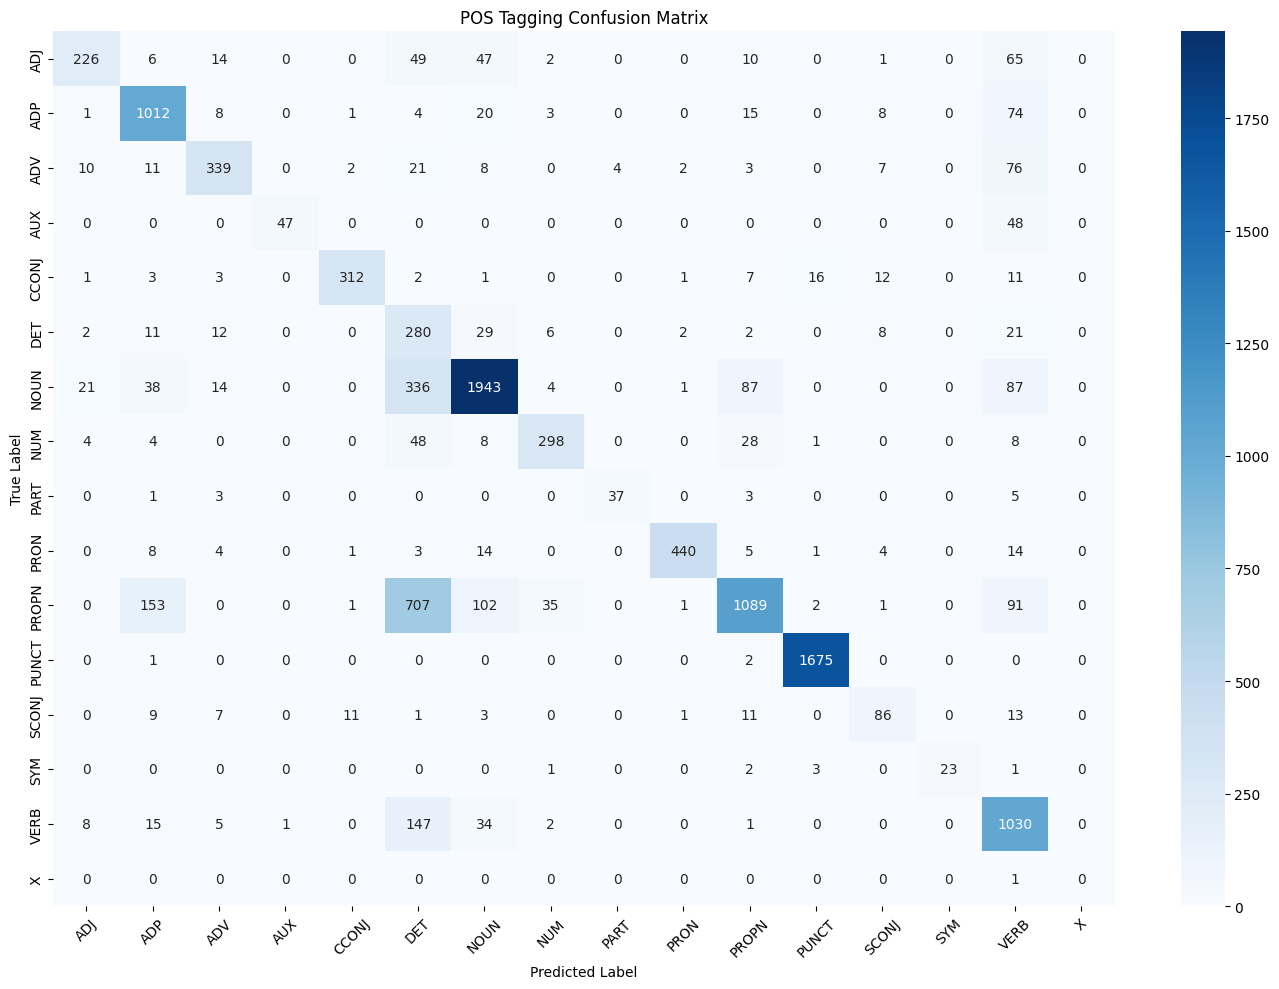

In [11]:
print("\n--- Classification Report ---")
acc = accuracy_score(y_true_names, y_pred_names)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_true_names, y_pred_names, zero_division=0))

print("Generating Confusion Matrix...")
cm = confusion_matrix(y_true_names, y_pred_names, labels=labels)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('POS Tagging Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()